In [6]:
from micrograd import Value
from micrograd.nn import Neuron, Layer, MLP
import numpy as np
import matplotlib.pyplot as plt

In [7]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([-1, 1, 1, -1])

In [8]:
model = MLP(2, [16, 8, 4, 1])

In [9]:
def loss(batch_size=None):
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(len(X))[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    scores = list(map(model, inputs))
    losses = [(1 + -yi * scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = (sum(losses) * 1.0) / len(losses)
    Lambda = 1e-4
    reg_loss = Lambda * sum((p * p) for p in model.parameters())
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    total_loss = data_loss + reg_loss
    return total_loss, sum(accuracy) / len(accuracy)

In [10]:
for k in range(1000):
    total_loss, acc = loss()
    model.zero_grad()
    total_loss.backward()
    learning_rate = 0.05 * (0.99 ** k)
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    if k % 100 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc * 100}%")

step 0 loss 0.9716564742888061, accuracy 75.0%
step 100 loss 0.06255145534944137, accuracy 100.0%
step 200 loss 0.006554892454713094, accuracy 100.0%
step 300 loss 0.006553779019630987, accuracy 100.0%
step 400 loss 0.006553371513785578, accuracy 100.0%
step 500 loss 0.006553222359817604, accuracy 100.0%
step 600 loss 0.006553167765492331, accuracy 100.0%
step 700 loss 0.0065531477823176296, accuracy 100.0%
step 800 loss 0.006553140467844675, accuracy 100.0%
step 900 loss 0.006553137790513067, accuracy 100.0%


In [11]:
scores = [model(list(map(Value, xrow))).data for xrow in X]
print("scores:", scores)
print("predictions:", [1 if score > 0 else -1 for score in scores])

scores: [np.float64(-1.0064504039965592), np.float64(1.0307259665817523), np.float64(1.1019923641895228), np.float64(-1.0064504039965592)]
predictions: [-1, 1, 1, -1]


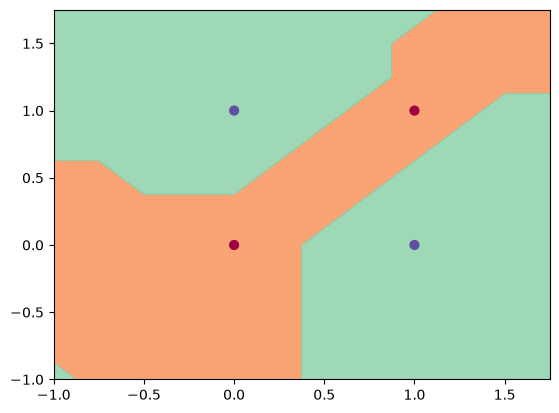

In [12]:
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores]).reshape(xx.shape)
plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()